In [ ]:
# import cshogi.CSA as CSA

# kifu = CSA.Parser.parse_file("../data/sample.csa")
# print(kifu)

FileNotFoundError: [Errno 2] No such file or directory: '../data/sample.csa'

In [ ]:

# kifu = CSA.Parser.parse_file("../data/sample.csa")[0]

# print("対局者（先手）:", kifu.names[0])
# print("対局者（後手）:", kifu.names[1])
# print("勝者:", kifu.win)
# print("手数:", len(kifu.moves))
# print("最初の5手:", kifu.moves[:5])

FileNotFoundError: [Errno 2] No such file or directory: '../data/sample.csa'

In [26]:
import cshogi

board = cshogi.Board()
for move in kifu.moves[:10]:
    print(cshogi.move_to_csa(move))
    board.push(move)

NameError: name 'kifu' is not defined

In [46]:
import cshogi.KIF as KIF
import os

data_dir = "../data/"
kifus = []

for filename in os.listdir(data_dir):
    if filename.endswith(".kif"):
        filepath = os.path.join(data_dir, filename)
        try:
            kifu = KIF.Parser.parse_file(filepath)
            kifus.append(kifu[0])
        except UnicodeDecodeError:
            try:
                with open(filepath, encoding="utf-8") as f:
                    content = f.read()
                kifu = KIF.Parser.parse_str(content)
                kifus.append(kifu)
            except Exception as e:
                print(f"スキップ: {filename}, エラー: {e}")
                continue

print(f"読み込んだ棋譜数: {len(kifus)}")
print(f"最初の棋譜の対局者: {kifus[0].names}")

読み込んだ棋譜数: 1
最初の棋譜の対局者: ['伊藤匠 叡王', '斎藤慎太郎 八段']


In [ ]:
# records = []

# for kifu in kifus:
#     # 手数が奇数→先手が最後に指して後手が投了→先手の勝ち
#     # 手数が偶数→後手が最後に指して先手が投了→後手の勝ち
#     moves_count = len(kifu.moves)
#     if moves_count % 2 == 1:
#         winner = kifu.names[0]  # 先手の勝ち
#     else:
#         winner = kifu.names[1]  # 後手の勝ち

#     record = {
#         "先手": kifu.names[0],
#         "後手": kifu.names[1],
#         "勝者": winner,
#         "手数": moves_count,
#     }
#     records.append(record)

# df = pd.DataFrame(records)
# print(df)

NameError: name 'pd' is not defined

In [45]:
kifu = kifus[0]
print(dir(kifu))

IndexError: list index out of range

In [ ]:
kifu = kifus[0]
print("win:", kifu.win)
print("endgame:", kifu.endgame)

In [ ]:
with open("../data/" + os.listdir(data_dir)[0], encoding="utf-8") as f:
    print(f.read())

In [ ]:
import re

def normalize_name(name):
    # 全角・半角スペースを除去して、段位・タイトルも除去
    name = re.sub(r'[\u3000\s]', '', name)  # スペース除去
    name = re.sub(r'(九段|八段|七段|六段|五段|四段|三段|二段|初段|名人|竜王|王位|王座|棋王|王将|棋聖|叡王|二冠|三冠|四冠|五冠|六冠|七冠)', '', name)
    return name

# 確認
for kifu in kifus:
    print(normalize_name(kifu.names[0]), "vs", normalize_name(kifu.names[1]))
    

In [92]:
import cshogi.KIF as KIF
import pandas as pd
import os
import re

def normalize_name(name):
    name = re.sub(r'[\u3000\s・]', '', name)  # ・を追加
    name = re.sub(r'(九段|八段|七段|六段|五段|四段|三段|二段|初段|名人|竜王|王位|王座|棋王|王将|棋聖|叡王|二冠|三冠|四冠|五冠|六冠|七冠)', '', name)
    return name

data_dir = "../data/"
records = []

for player_dir in os.listdir(data_dir):
    player_path = os.path.join(data_dir, player_dir)
    if not os.path.isdir(player_path):
        continue
    for filename in os.listdir(player_path):
        if filename.endswith(".kif"):
            filepath = os.path.join(player_path, filename)
            try:
                kifu = KIF.Parser.parse_file(filepath)
            except UnicodeDecodeError:
                try:
                    with open(filepath, encoding="utf-8") as f:
                        content = f.read()
                    kifu = [KIF.Parser.parse_str(content)]
                except Exception as e:
                    print(f"スキップ: {filename}, エラー: {e}")
                    continue
            for k in kifu:
                moves_count = len(k.moves)
                if moves_count == 0:
                    continue
                winner = normalize_name(k.names[0]) if moves_count % 2 == 1 else normalize_name(k.names[1])
                records.append({
                    "棋士フォルダ": player_dir,
                    "先手": normalize_name(k.names[0]),
                    "後手": normalize_name(k.names[1]),
                    "勝者": winner,
                    "手数": moves_count,
                })

df = pd.DataFrame(records)
print(f"総棋譜数: {len(df)}")
# print(df.head(10))
print(df[df["棋士フォルダ"]=="藤井聡太"])

総棋譜数: 250
    棋士フォルダ     先手        後手        勝者   手数
150   藤井聡太   永瀬拓矢      藤井聡太      永瀬拓矢  137
151   藤井聡太  佐々木勇気      藤井聡太      藤井聡太   68
152   藤井聡太   藤井聡太      杉本和陽      藤井聡太   87
153   藤井聡太   増田康宏      藤井聡太      藤井聡太  114
154   藤井聡太   藤井聡太       伊藤匠       伊藤匠  116
155   藤井聡太   藤井聡太      千田翔太      藤井聡太  131
156   藤井聡太   藤井聡太     佐々木勇気      藤井聡太   75
157   藤井聡太    伊藤匠      藤井聡太       伊藤匠  103
158   藤井聡太    伊藤匠      藤井聡太       伊藤匠   97
159   藤井聡太   藤井聡太      永瀬拓矢      藤井聡太  131
160   藤井聡太   藤井聡太      山崎隆之      藤井聡太  127
161   藤井聡太   藤井聡太      増田康宏      増田康宏  118
162   藤井聡太   杉本和陽      藤井聡太      藤井聡太  144
163   藤井聡太   永瀬拓矢      藤井聡太      永瀬拓矢  107
164   藤井聡太   永瀬拓矢      藤井聡太      永瀬拓矢   91
165   藤井聡太   増田康宏  藤井聡太NHK杯  藤井聡太NHK杯  122
166   藤井聡太   増田康宏      藤井聡太      藤井聡太  126
167   藤井聡太  佐々木勇気      藤井聡太      藤井聡太  138
168   藤井聡太   藤井聡太      増田康宏      藤井聡太   77
169   藤井聡太   藤井聡太       伊藤匠      藤井聡太   99
170   藤井聡太   藤井聡太      永瀬拓矢      藤井聡太   89
171   藤井聡太   藤井聡太      永瀬拓矢      藤井聡太  103
1

In [97]:
target_players = ['羽生善治', '伊藤匠', '藤井聡太', '菅井竜也', '渡辺明']

records_player = []

for player in target_players:
    player_df = df[df['棋士フォルダ'] == player]
    
    total = len(player_df)
    wins = (player_df['勝者'] == player).sum()
    
    records_player.append({
        '棋士': player,
        '総対局数': total,
        '勝利数': wins,
        '敗北数': total - wins,
        '勝率': round(wins / total, 3),
        '平均手数': round(player_df['手数'].mean(), 1),
    })

summary_df = pd.DataFrame(records_player)
print(summary_df)

     棋士  総対局数  勝利数  敗北数    勝率   平均手数
0  羽生善治    50   32   18  0.64  109.9
1   伊藤匠    50   37   13  0.74  108.4
2  藤井聡太    50   37   13  0.74  109.3
3  菅井竜也    50   24   26  0.48  120.2
4   渡辺明    50   22   28  0.44  108.8


In [ ]:
# records_player = []

# for player in target_players:
#     player_df = df[df['棋士フォルダ'] == player]
    
#     total = len(player_df)
#     wins = (player_df['勝者'] == player).sum()
    
#     # 先手・後手別勝率
#     sente_df = player_df[player_df['先手'] == player]
#     gote_df = player_df[player_df['後手'] == player]
#     sente_wins = (sente_df['勝者'] == player).sum()
#     gote_wins = (gote_df['勝者'] == player).sum()
    
#     records_player.append({
#         '棋士': player,
#         '勝率': round(wins / total, 3),
#         '平均手数': round(player_df['手数'].mean(), 1),
#         '先手勝率': round(sente_wins / len(sente_df), 3) if len(sente_df) > 0 else 0,
#         '後手勝率': round(gote_wins / len(gote_df), 3) if len(gote_df) > 0 else 0,
#         '短期決戦率': round((player_df['手数'] < 100).sum() / total, 3),
#         '長期戦率': round((player_df['手数'] > 130).sum() / total, 3),
#     })

# summary_df = pd.DataFrame(records_player)
# print(summary_df)

     棋士    勝率   平均手数   先手勝率   後手勝率  短期決戦率  長期戦率
0  羽生善治  0.64  109.9  0.630  0.652   0.42  0.20
1   伊藤匠  0.74  108.4  0.720  0.760   0.38  0.12
2  藤井聡太  0.74  109.3  0.792  0.720   0.42  0.24
3  菅井竜也  0.48  120.2  0.583  0.385   0.26  0.30
4   渡辺明  0.44  108.8  0.375  0.520   0.44  0.20


In [98]:
target_players = ['羽生善治', '伊藤匠', '藤井聡太', '菅井竜也', '渡辺明']

records_player = []

for player in target_players:
    player_df = df[df['棋士フォルダ'] == player]
    total = len(player_df)
    wins = (player_df['勝者'] == player).sum()
    sente_df = player_df[player_df['先手'] == player]
    gote_df = player_df[player_df['後手'] == player]
    sente_wins = (sente_df['勝者'] == player).sum()
    gote_wins = (gote_df['勝者'] == player).sum()
    win_df = player_df[player_df['勝者'] == player]
    lose_df = player_df[player_df['勝者'] != player]

    records_player.append({
        '棋士': player,
        '勝率': round(wins / total, 3),
        '平均手数': round(player_df['手数'].mean(), 1),
        '先手勝率': round(sente_wins / len(sente_df), 3) if len(sente_df) > 0 else 0,
        '後手勝率': round(gote_wins / len(gote_df), 3) if len(gote_df) > 0 else 0,
        '短期決戦率': round((player_df['手数'] < 100).sum() / total, 3),
        '長期戦率': round((player_df['手数'] > 130).sum() / total, 3),
        '勝利時平均手数': round(win_df['手数'].mean(), 1),
        '敗北時平均手数': round(lose_df['手数'].mean(), 1),
        '振り飛車率': round((player_df['戦型'] == '振り飛車').sum() / total, 3),
    })

summary_df = pd.DataFrame(records_player)
print(summary_df)

KeyError: '戦型'

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Hiragino Sans'  # Mac日本語フォント

features = ['勝率', '平均手数', '先手勝率', '後手勝率', '短期決戦率', '長期戦率']
X = summary_df[features].values

# 正規化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# クラスタリング
kmeans = KMeans(n_clusters=3, random_state=42)
summary_df['クラスタ'] = kmeans.fit_predict(X_scaled)

print(summary_df[['棋士', 'クラスタ']])

     棋士  クラスタ
0  羽生善治     2
1   伊藤匠     0
2  藤井聡太     2
3  菅井竜也     1
4   渡辺明     2


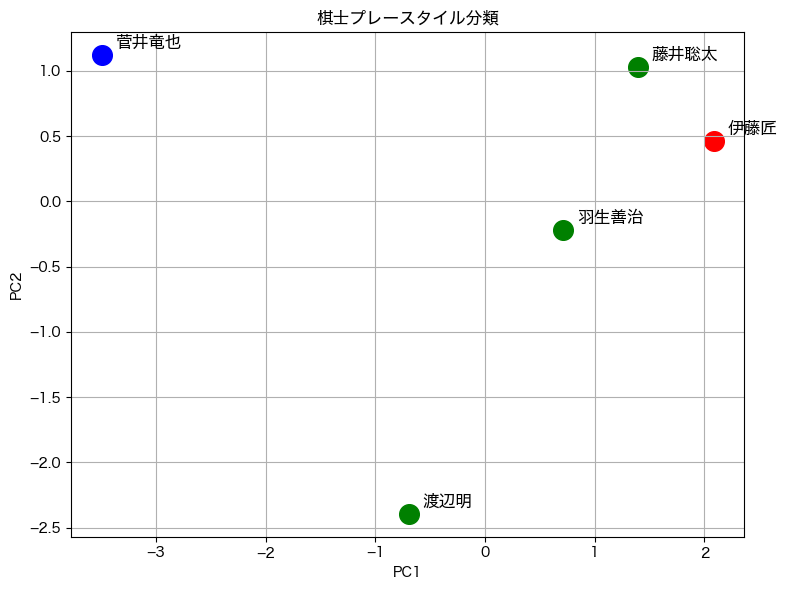

In [70]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']

for i, row in summary_df.iterrows():
    cluster = row['クラスタ']
    plt.scatter(X_pca[i, 0], X_pca[i, 1], 
                color=colors[cluster], s=200)
    plt.annotate(row['棋士'], 
                (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points",
                xytext=(10, 5),
                fontsize=12)

plt.title('棋士プレースタイル分類')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
pca_df = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1', 'PC2']
)
print(pca_df.round(3))

        勝率   平均手数   先手勝率  後手勝率  短期決戦率   長期戦率
PC1  0.423 -0.450  0.272  0.50  0.364 -0.402
PC2  0.426  0.346  0.649  0.12 -0.454  0.238


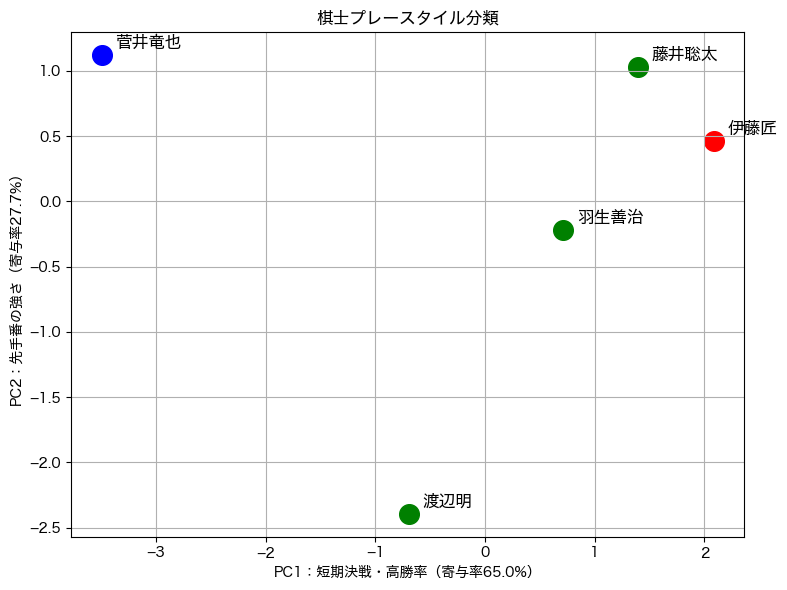

In [72]:
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']

for i, row in summary_df.iterrows():
    cluster = row['クラスタ']
    plt.scatter(X_pca[i, 0], X_pca[i, 1],
                color=colors[cluster], s=200)
    plt.annotate(row['棋士'],
                (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points",
                xytext=(10, 5),
                fontsize=12)

plt.title('棋士プレースタイル分類')
plt.xlabel(f'PC1：短期決戦・高勝率（寄与率{pca.explained_variance_ratio_[0]:.1%}）')
plt.ylabel(f'PC2：先手番の強さ（寄与率{pca.explained_variance_ratio_[1]:.1%}）')
plt.grid(True)
plt.tight_layout()
plt.show()

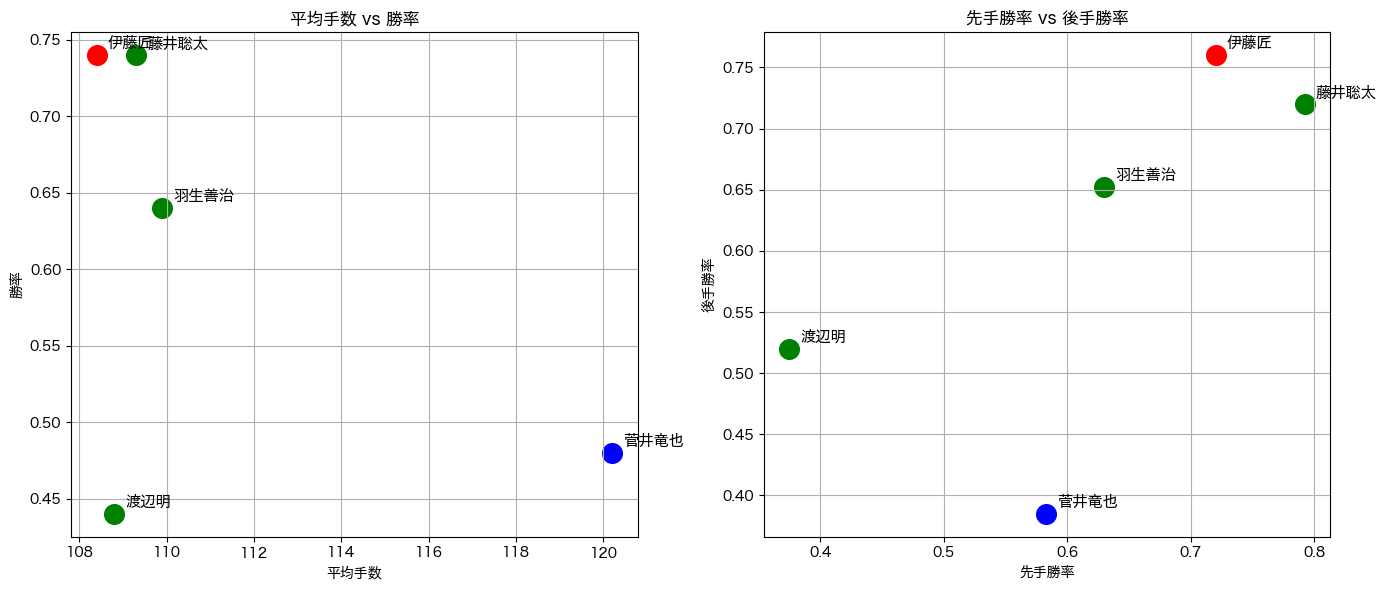

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左：平均手数 vs 勝率
for i, row in summary_df.iterrows():
    axes[0].scatter(row['平均手数'], row['勝率'], 
                   color=colors[row['クラスタ']], s=200)
    axes[0].annotate(row['棋士'], (row['平均手数'], row['勝率']),
                    textcoords="offset points", xytext=(8, 5), fontsize=11)
axes[0].set_xlabel('平均手数')
axes[0].set_ylabel('勝率')
axes[0].set_title('平均手数 vs 勝率')
axes[0].grid(True)

# 右：先手勝率 vs 後手勝率
for i, row in summary_df.iterrows():
    axes[1].scatter(row['先手勝率'], row['後手勝率'],
                   color=colors[row['クラスタ']], s=200)
    axes[1].annotate(row['棋士'], (row['先手勝率'], row['後手勝率']),
                    textcoords="offset points", xytext=(8, 5), fontsize=11)
axes[1].set_xlabel('先手勝率')
axes[1].set_ylabel('後手勝率')
axes[1].set_title('先手勝率 vs 後手勝率')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [74]:
kifu = kifus[0]
print(kifu.var_info)

{'開始日時': '2025/06/18 10:00:00', '終了日時': '2025/06/19 0:11:00', '棋戦': '順位戦', '場所': '東京・将棋会館', '持ち時間': '6時間', '消費時間': '123▲360△360', '戦型': '横歩取り'}


In [75]:
# 関数定義
def classify_style(sentype):
    if sentype is None:
        return 'unknown'
    furibisha = ['四間飛車', '三間飛車', '中飛車', '向かい飛車', '振り飛車', '石田流', '角交換振り飛車']
    for f in furibisha:
        if f in sentype:
            return '振り飛車'
    return '居飛車'

# 確認
for k in kifus[:5]:
    sentype = k.var_info.get('戦型', None)
    print(classify_style(sentype), ':', sentype)

居飛車 : 横歩取り
居飛車 : 雁木
居飛車 : 雁木
居飛車 : 角換わりその他
居飛車 : 角換わりその他


In [76]:
print(len(kifus))

250


In [77]:
import cshogi.KIF as KIF
import pandas as pd
import os
import re

def normalize_name(name):
    name = re.sub(r'[\u3000\s]', '', name)
    name = re.sub(r'(九段|八段|七段|六段|五段|四段|三段|二段|初段|名人|竜王|王位|王座|棋王|王将|棋聖|叡王|二冠|三冠|四冠|五冠|六冠|七冠)', '', name)
    return name

def classify_style(sentype):
    if sentype is None:
        return 'unknown'
    furibisha = ['四間飛車', '三間飛車', '中飛車', '向かい飛車', '振り飛車', '石田流', '角交換振り飛車']
    for f in furibisha:
        if f in sentype:
            return '振り飛車'
    return '居飛車'

data_dir = "../data/"
kifus = []
records = []

for player_dir in os.listdir(data_dir):
    player_path = os.path.join(data_dir, player_dir)
    if not os.path.isdir(player_path):
        continue
    for filename in os.listdir(player_path):
        if filename.endswith(".kif"):
            filepath = os.path.join(player_path, filename)
            try:
                kifu = KIF.Parser.parse_file(filepath)
            except UnicodeDecodeError:
                try:
                    with open(filepath, encoding="utf-8") as f:
                        content = f.read()
                    kifu = [KIF.Parser.parse_str(content)]
                except Exception as e:
                    print(f"スキップ: {filename}, エラー: {e}")
                    continue
            for k in kifu:
                moves_count = len(k.moves)
                if moves_count == 0:
                    continue
                winner = normalize_name(k.names[0]) if moves_count % 2 == 1 else normalize_name(k.names[1])
                kifus.append(k)
                records.append({
                    '棋士フォルダ': player_dir,
                    '先手': normalize_name(k.names[0]),
                    '後手': normalize_name(k.names[1]),
                    '勝者': winner,
                    '手数': moves_count,
                    '戦型': classify_style(k.var_info.get('戦型', None)),
                })

df = pd.DataFrame(records)
print(f"総棋譜数: {len(df)}")
print(df.head())

総棋譜数: 250
  棋士フォルダ                 先手     後手                 勝者   手数   戦型
0   羽生善治               羽生善治  斎藤明日斗               羽生善治  123  居飛車
1   羽生善治  SUNTORY将棋オールスター東西   羽生善治  SUNTORY将棋オールスター東西  135  居飛車
2   羽生善治                本田奎   羽生善治               羽生善治   88  居飛車
3   羽生善治               羽生善治   木村一基               羽生善治  147  居飛車
4   羽生善治              佐々木大地   羽生善治               羽生善治  104  居飛車


In [86]:
target_players = ['羽生善治', '伊藤匠', '藤井聡太', '菅井竜也', '渡辺明']

records_player = []

for player in target_players:
    player_df = df[df['棋士フォルダ'] == player]
    
    total = len(player_df)
    wins = (player_df['勝者'] == player).sum()
    sente_df = player_df[player_df['先手'] == player]
    gote_df = player_df[player_df['後手'] == player]
    sente_wins = (sente_df['勝者'] == player).sum()
    gote_wins = (gote_df['勝者'] == player).sum()
    win_df = player_df[player_df['勝者'] == player]
    lose_df = player_df[player_df['勝者'] != player]

    records_player.append({
        '棋士': player,
        '勝率': round(wins / total, 3),
        '平均手数': round(player_df['手数'].mean(), 1),
        '先手勝率': round(sente_wins / len(sente_df), 3) if len(sente_df) > 0 else 0,
        '後手勝率': round(gote_wins / len(gote_df), 3) if len(gote_df) > 0 else 0,
        '短期決戦率': round((player_df['手数'] < 100).sum() / total, 3),
        '長期戦率': round((player_df['手数'] > 130).sum() / total, 3),
        '勝利時平均手数': round(win_df['手数'].mean(), 1),
        '敗北時平均手数': round(lose_df['手数'].mean(), 1),
        '振り飛車率': round((player_df['戦型'] == '振り飛車').sum() / total, 3),
    })

summary_df = pd.DataFrame(records_player)
print(summary_df)

     棋士    勝率   平均手数   先手勝率   後手勝率  短期決戦率  長期戦率  勝利時平均手数  敗北時平均手数  振り飛車率
0  羽生善治  0.64  109.9  0.630  0.652   0.42  0.20    111.5    107.0   0.16
1   伊藤匠  0.74  108.4  0.720  0.760   0.38  0.12    109.2    105.8   0.18
2  藤井聡太  0.50  109.3  0.737  0.647   0.42  0.24    106.8    111.8   0.14
3  菅井竜也  0.48  120.2  0.583  0.385   0.26  0.30    128.0    113.0   0.90
4   渡辺明  0.44  108.8  0.375  0.520   0.44  0.20    105.5    111.4   0.08


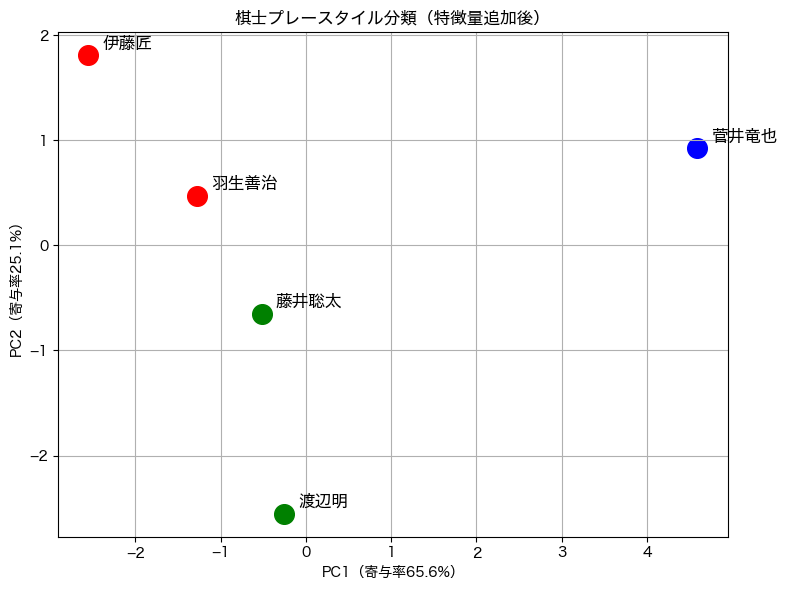

     棋士  クラスタ
0  羽生善治     0
1   伊藤匠     0
2  藤井聡太     2
3  菅井竜也     1
4   渡辺明     2


In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Hiragino Sans'

features = ['勝率', '平均手数', '先手勝率', '後手勝率', '短期決戦率', '長期戦率', '勝利時平均手数', '敗北時平均手数', '振り飛車率']
X = summary_df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
summary_df['クラスタ'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = ['red', 'blue', 'green']
plt.figure(figsize=(8, 6))
for i, row in summary_df.iterrows():
    plt.scatter(X_pca[i, 0], X_pca[i, 1],
                color=colors[row['クラスタ']], s=200)
    plt.annotate(row['棋士'], (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(10, 5), fontsize=12)

plt.title('棋士プレースタイル分類（特徴量追加後）')
plt.xlabel(f'PC1（寄与率{pca.explained_variance_ratio_[0]:.1%}）')
plt.ylabel(f'PC2（寄与率{pca.explained_variance_ratio_[1]:.1%}）')
plt.grid(True)
plt.tight_layout()
plt.show()

print(summary_df[['棋士', 'クラスタ']])


In [84]:
pca_df = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1', 'PC2']
)
print(pca_df.round(3))

        勝率   平均手数   先手勝率   後手勝率  短期決戦率   長期戦率  勝利時平均手数  敗北時平均手数  振り飛車率
PC1 -0.261  0.392 -0.114 -0.386 -0.332  0.370    0.355    0.321  0.374
PC2  0.500  0.198  0.478  0.199 -0.369 -0.118    0.319   -0.342  0.271


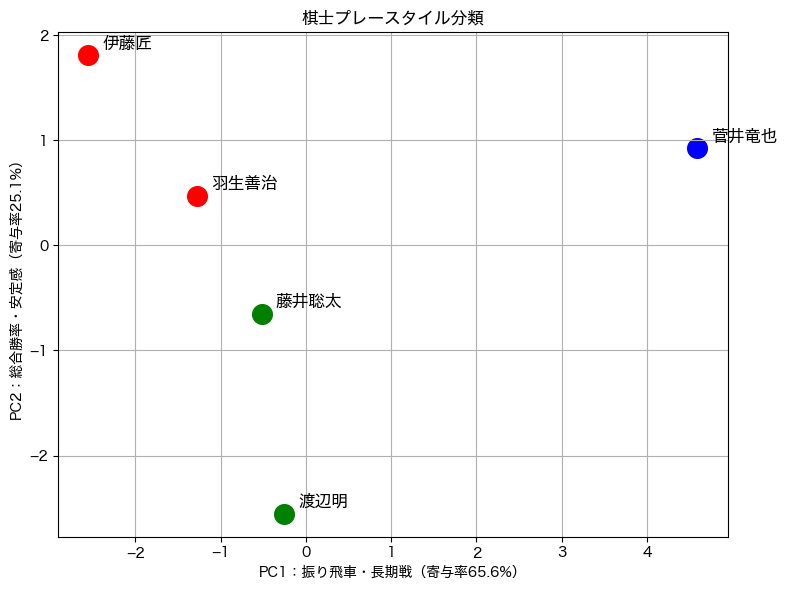

In [83]:
colors = ['red', 'blue', 'green']
plt.figure(figsize=(8, 6))
for i, row in summary_df.iterrows():
    plt.scatter(X_pca[i, 0], X_pca[i, 1],
                color=colors[row['クラスタ']], s=200)
    plt.annotate(row['棋士'], (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(10, 5), fontsize=12)

plt.title('棋士プレースタイル分類')
plt.xlabel(f'PC1：振り飛車・長期戦（寄与率{pca.explained_variance_ratio_[0]:.1%}）')
plt.ylabel(f'PC2：総合勝率・安定感（寄与率{pca.explained_variance_ratio_[1]:.1%}）')
plt.grid(True)
plt.tight_layout()
plt.show()

     棋士    勝率   平均手数   先手勝率   後手勝率  短期決戦率  長期戦率  勝利時平均手数  敗北時平均手数  振り飛車率
0  羽生善治  0.64  109.9  0.630  0.652   0.42  0.20    111.5    107.0   0.16
1   伊藤匠  0.74  108.4  0.720  0.760   0.38  0.12    109.2    105.8   0.18
2  藤井聡太  0.50  109.3  0.737  0.647   0.42  0.24    106.8    111.8   0.14
3  菅井竜也  0.48  120.2  0.583  0.385   0.26  0.30    128.0    113.0   0.90
4   渡辺明  0.44  108.8  0.375  0.520   0.44  0.20    105.5    111.4   0.08
